In [1]:
#imports, necassary environments, and data upload

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.decomposition import PCA
import umap.umap_ as umap
from sklearn.manifold import TSNE


#!pip install kneed
#!pip install umap-learn


day2usvLst = pd.read_csv(
    r"SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day2Session1_01282026_IZ\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day2Session1_01282026_IZ_USV_rated_YO.csv"
)
day2df = pd.read_csv(
    r"SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day2Session1_01282026_IZ\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day2Session1_01282026_IZ_USV.csv"
)

day5usvLst = pd.read_csv(
    r"SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day5Session1_02032026_YO\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day5Session1_02032026_YO_USV_rated_YO.csv"
)
day5df = pd.read_csv(
    r"SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day5Session1_02032026_YO\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day5Session1_02032026_YO_USV.csv"
)

day9usvLst = pd.read_csv(
    r"SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day9Session1_02102026_YO\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day9Session1_02102026_YO_USV_rated_YO.csv"
)
day9df = pd.read_csv(
    r"SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day9Session1_02102026_YO\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day9Session1_02102026_YO_USV.csv"
)
day16usvLst = pd.read_csv(
    r"SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day16Session1_02242026_YO\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day16Session1_02242026_YO_USV_rated_YO.csv"
)
day16df = pd.read_csv(
    r"SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day16Session1_02242026_YO\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day16Session1_02242026_YO_USV.csv"
)

In [2]:
# get allowed USV labels from rated file
valid_usvs2 = day2usvLst["0"]

# keep only matching USVs
day2df_filtered = day2df[
    day2df["label"].isin(valid_usvs2)
]
day2df_filtered = day2df_filtered[
    day2df_filtered["trial_num"] == 3
]

In [3]:
# get allowed USV labels from rated file
valid_usvs5 = day5usvLst["0"]

# keep only matching USVs
day5df_filtered = day5df[
    day5df["label"].isin(valid_usvs5)
]
day5df_filtered = day5df_filtered[
    day5df_filtered["trial_num"] == 3
]

In [4]:
# get allowed USV labels from rated file
valid_usvs9 = day9usvLst["0"]

# keep only matching USVs
day9df_filtered = day9df[
    day9df["label"].isin(valid_usvs9)
]
day16df_filtered = day9df_filtered[
    day9df_filtered["trial_num"] == 3
]

In [5]:
# get allowed USV labels from rated file
valid_usvs16 = day16usvLst["0"]

# keep only matching USVs
day16df_filtered = day16df[
    day16df["label"].isin(valid_usvs16)
]
day16df_filtered = day16df_filtered[
    day16df_filtered["trial_num"] == 3
]

In [6]:
#Sanity check
print(day2df_filtered.columns)
day2df_filtered.head()

Index(['start', 'stop', 'label', 'duration', 'trial_num', 'rms', 'zcr',
       'centroid', 'bandwidth', 'flatness', 'rolloff', 'f0', 'contrast1',
       'contrast2', 'contrast3', 'contrast4', 'contrast5', 'contrast6',
       'contrast7'],
      dtype='object')


,start,stop,label,duration,trial_num,rms,zcr,centroid,bandwidth,flatness,rolloff,f0,contrast1,contrast2,contrast3,contrast4,contrast5,contrast6,contrast7
1081,955.97,955.982,USV_1082,0.012,3,0.010005,0.025077,17034.936559,20482.087644,0.000517,33133.928571,29213.126228,1.843791,5.960135,6.451093,16.050087,8.207591,14.792652,40.139764


In [7]:
#Data Processing

# create lst of desired features
features = [
    "duration",
    "rms",
    "zcr",
    "centroid",
    "bandwidth",
    "flatness",
    "rolloff",
    "f0",
    'contrast1', 'contrast2', 'contrast3', 'contrast4','contrast5', 'contrast6', 'contrast7'
]

# slice dataframe and only keep desired features.
df_features5 = day5df_filtered[features]

# separate numeric data from non numeric for clustering
X5 = df_features5.select_dtypes(include=["number"])
X5 = X5.fillna(0) #if data is non, change to 0
meta5 = df_features5.select_dtypes(exclude=["number"])

#normalize feature values
scaler = StandardScaler() #create scalar object
X_scaled5 = scaler.fit_transform(X5) #use scalar object to normalize
#X_scaled5=X5

In [8]:
# slice dataframe and only keep desired features.
df_features9 = day9df_filtered[features]

# separate numeric data from non numeric for clustering
X9 = df_features9.select_dtypes(include=["number"])
X9 = X9.fillna(0) #if data is non, change to 0
meta9 = df_features9.select_dtypes(exclude=["number"])

#normalize feature values
scaler = StandardScaler() #create scalar object
X_scaled9 = scaler.fit_transform(X9) #use scalar object to normalize
#X_scaled9=X9

In [9]:
# slice dataframe and only keep desired features.
df_features16 = day16df_filtered[features]

# separate numeric data from non numeric for clustering
X16 = df_features16.select_dtypes(include=["number"])
X16 = X16.fillna(0) #if data is non, change to 0
meta16 = df_features16.select_dtypes(exclude=["number"])

#normalize feature values
scaler = StandardScaler() #create scalar object
X_scaled16 = scaler.fit_transform(X16) #use scalar object to normalize
#X_scaled=X

In [10]:
#Find optimal k value
k_range = range(1, 30) # init range of possible k values
wss = [] # init list that will hold within cluster sum of squares (wss, inertia)

# for rach k value in the preset range
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10) #create kmeans obj, n_init = number of times to run kmeans with diff random starts
    km.fit(X_scaled9) #run kmmeans on data
    wss.append(km.inertia_) # for the current k value, add the wss to the list


C:\Users\scott\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\scott\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\scott\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\scott\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

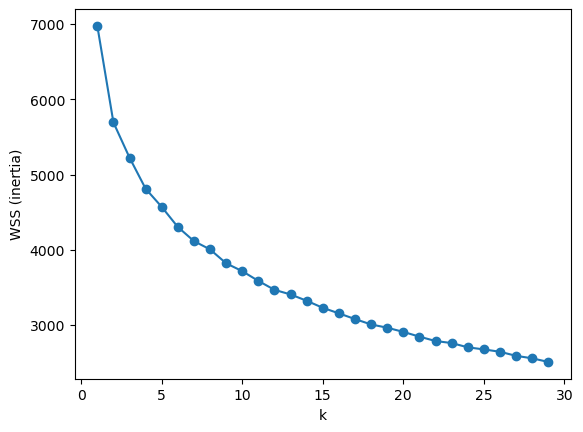

In [11]:
#plot wss loss

plt.plot(k_range, wss, marker='o')
plt.xlabel("k")
plt.ylabel("WSS (inertia)")
plt.show()

In [12]:
# Find the knee
kneedle = KneeLocator(k_range, wss, curve='convex', direction='decreasing') # wss shoud be decreasing with a downward curve
optimal_k = kneedle.elbow #gives elbow value

print("Optimal k:", optimal_k)

Optimal k: 9


In [13]:
#create k means object
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
# run k means on data, add cluster assignment labels to datapoints
labels = kmeans.fit_predict(X_scaled9)

C:\Users\scott\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [14]:
#Dimensionality reduction (PCA) 
pca = PCA(n_components=2)   # create PCA object
X_pca9 = pca.fit_transform(X_scaled9)   # fit PCA to data
X_pca5 = pca.fit_transform(X_scaled5)   # fit PCA to data

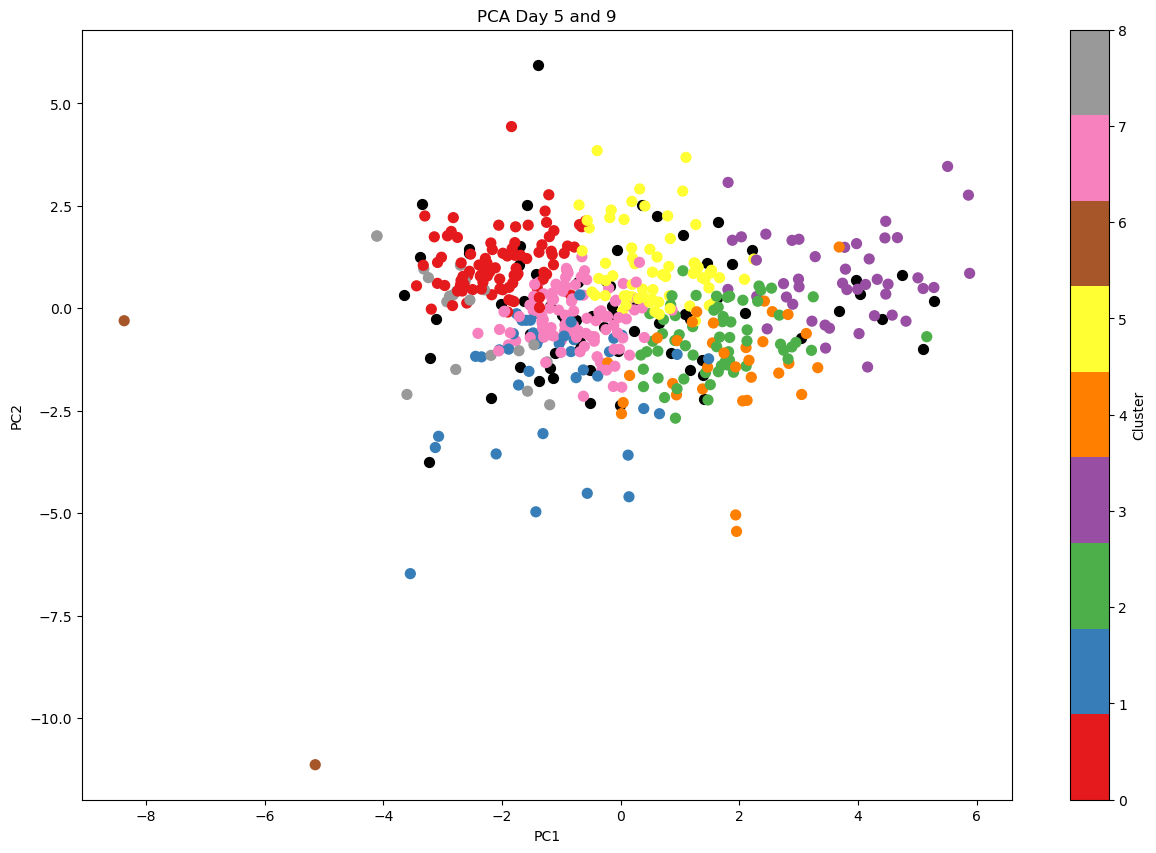

In [15]:
# Visualize clusters (PCA)

#plot data
plt.figure(figsize=(15,10))
scatter = plt.scatter(
    X_pca5[:,0],
    X_pca5[:,1],
    color='black',
    s=50
)
scatter = plt.scatter(
    X_pca9[:,0],
    X_pca9[:,1],
    c=labels,
    cmap='Set1',
    s=50
)
plt.colorbar(scatter, label="Cluster")
plt.title("PCA Day 5 and 9")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [16]:
#Dimensionality reduction (UMAP) 

# initialize UMAP object
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=8,min_dist=0.01,metric='cosine',spread=3.0, )

# fit Umap model
X_umap9 = reducer.fit_transform(X_scaled9)
X_umap5 = reducer.fit_transform(X_scaled5)

C:\Users\scott\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


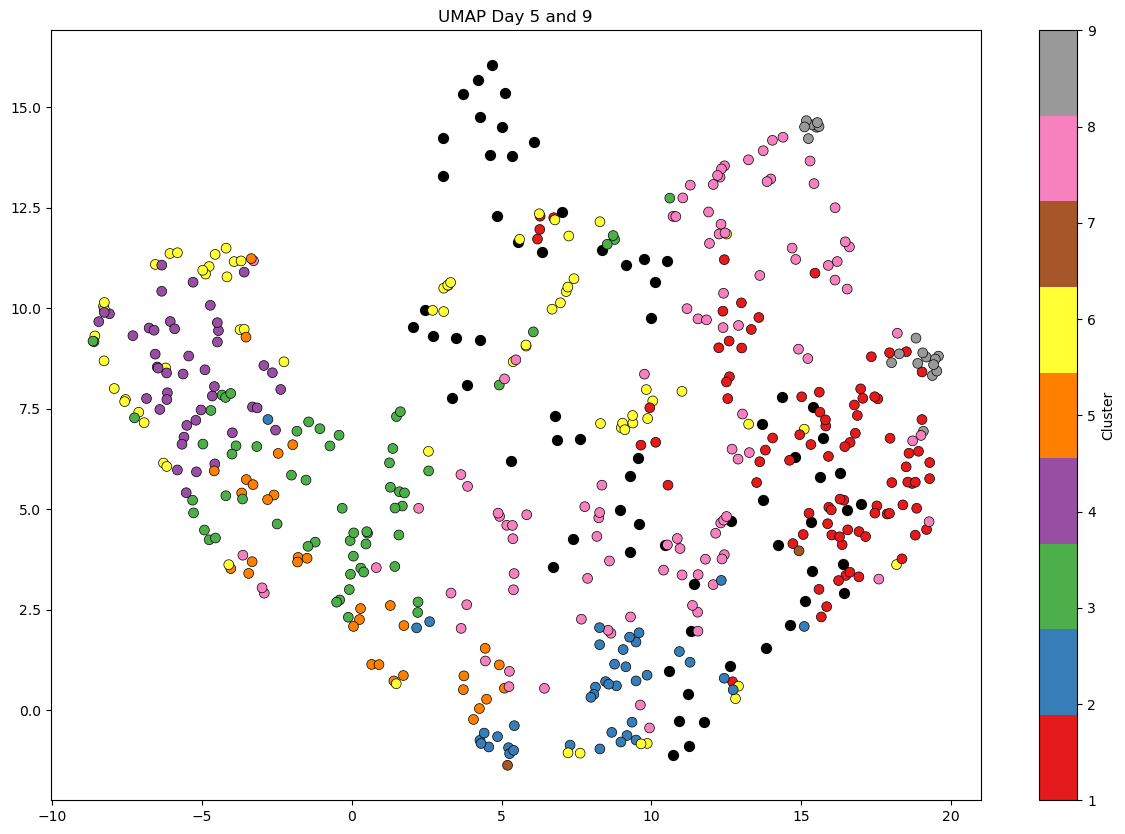

In [17]:
# Visualize clusters (UMAP)

plt.figure(figsize=(15,10))
scatter = plt.scatter(X_umap5[:, 0], X_umap5[:, 1], color="black", s=50)
scatter = plt.scatter(X_umap9[:, 0], X_umap9[:, 1], c=labels+1, s=50,cmap="Set1",edgecolors='black',linewidths=.5)

plt.colorbar(scatter, label="Cluster")
plt.title("UMAP Day 5 and 9")
plt.show()

In [30]:
#Dimensionality reduction (t-SNE) 
tsne = TSNE(
    n_components=2,
    perplexity=25,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne9 = tsne.fit_transform(X_scaled9)
X_tsne5 = tsne.fit_transform(X_scaled5)
X_tsne16 = tsne.fit_transform(X_scaled16)

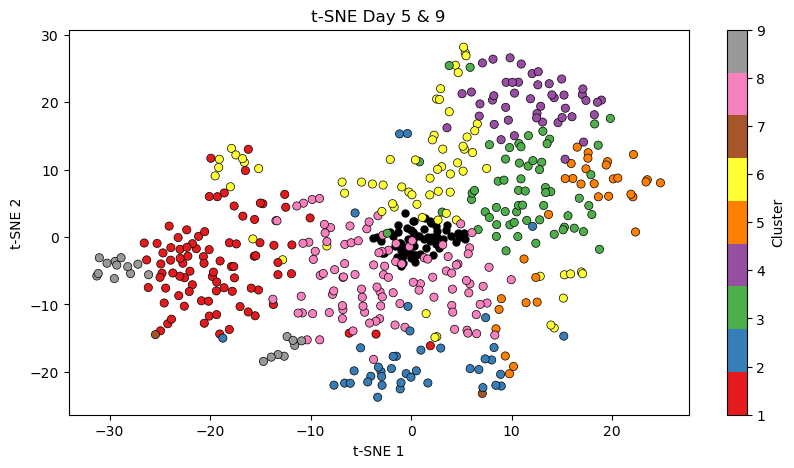

In [31]:
# Visualize clusters (tsne)

plt.figure(figsize=(10, 5))
scatter = plt.scatter(
    X_tsne5[:, 0],
    X_tsne5[:, 1],
    s=25,
    label= "Day 5",
    color = "black"
    
)

scatter = plt.scatter(
    X_tsne9[:, 0],
    X_tsne9[:, 1],
    c=labels+1,
    s=35,
    cmap="Set1",
    edgecolors='black',
    linewidths=.5
)


plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Day 5 & 9")
plt.colorbar(scatter, label="Cluster")
#plt.legend()
plt.show()